# Helene Cyclone Phase Space Diagram

---

## Overview

A significantly damaging aspect of Hurricane Helene was when the system became post-tropical, where it stalled centered over Tennessee due to having a Fujiwhara Effect with an extratropical cyclone in the region, in which orographic lifting and landslides occurred in the southern Appalachian Mountains. This notebook aims to analyze the system's transition from a warm-core system to a cold-core system, as well as overlaying radar imagery over a topographic map to portray the Fujiwhara Effect (time permiting).

1. Save a tracks.csv file of Hurricane Helene and a geopt.nc file of ERA5 geopotential at several pressure levels.
2. Utilize TempestExtremes' NodeFileCompose feature to take snapshots of the geopotential along Helene's track by inputting both files.
3. Calculate cyclone phase space (CPS) variables from the snaps.nc file created from NodeFileCompose and plot these variables by using the CPyS module.

---

## Imports

In [1]:
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import tropycal.tracks as tracks
import datetime as dt
from CPyS import compute_CPS_parameters
from CPyS import plot_CPS
from metpy.units import units

## Track File

Just like in the previous notebook, the tropycal package will be utilized to read the HURDAT2 data file, and then save a pandas dataframe of Helene. However, later in this notebook when TempestExtremes' NodeFileCompose feature imports this dataframe, it needs a column for the track ID, year, month, day, hour, minute, and second, so those are added in alongside the HURDAT2 data.

In [2]:
basin = tracks.TrackDataset(basin='north_atlantic',source='hurdat',include_btk=True)
helene = basin.get_storm(('helene',2024))
track = helene.to_dataframe()
track

--> Starting to read in HURDAT2 data
--> Completed reading in HURDAT2 data (2.4 seconds)
--> Starting to read in best track data
--> Completed reading in best track data (1.61 seconds)


,time,extra_obs,special,type,lat,lon,vmax,mslp,wmo_basin
0,2024-09-23 12:00:00,0,,DB,17.2,-81.7,30,1004,north_atlantic
1,2024-09-23 18:00:00,0,,DB,17.8,-81.9,35,1004,north_atlantic
2,2024-09-24 00:00:00,0,,DB,18.2,-82.2,35,1002,north_atlantic
3,2024-09-24 06:00:00,0,,DB,18.6,-82.8,35,1001,north_atlantic
4,2024-09-24 12:00:00,0,,TS,19.2,-83.7,40,999,north_atlantic
5,2024-09-24 18:00:00,0,,TS,19.4,-84.6,45,997,north_atlantic
6,2024-09-25 00:00:00,0,,TS,19.7,-85.2,50,990,north_atlantic
7,2024-09-25 06:00:00,0,,TS,20.3,-85.9,55,985,north_atlantic
8,2024-09-25 12:00:00,0,,HU,21.1,-86.2,65,979,north_atlantic
9,2024-09-25 18:00:00,0,,HU,22.0,-86.5,70,978,north_atlantic


In [3]:
# ERA5 has longitude from 0 - 360, so we convert the track longitude to match it
track['lon'] = track['lon'] + 360

# Define track_id column
track['track_id'] = "Helene" # This can be anything as long as if it different than other storm's IDs (if there are several storms)

# Define time columns
track['time'] = pd.to_datetime(track['time'])
track['year'] = track['time'].dt.year
track['month'] = track['time'].dt.month
track['day'] = track['time'].dt.day
track['hour'] = track['time'].dt.hour
track['minute'] = track['time'].dt.minute
track['second'] = track['time'].dt.second

# Save as tracks.csv
track = track[['track_id', 'time', 'lon', 'lat', 'year', 'month', 'day', 'hour', 'minute', 'second']]
track.to_csv("tracks.csv", index=False)
track

,track_id,time,lon,lat,year,month,day,hour,minute,second
0,Helene,2024-09-23 12:00:00,278.3,17.2,2024,9,23,12,0,0
1,Helene,2024-09-23 18:00:00,278.1,17.8,2024,9,23,18,0,0
2,Helene,2024-09-24 00:00:00,277.8,18.2,2024,9,24,0,0,0
3,Helene,2024-09-24 06:00:00,277.2,18.6,2024,9,24,6,0,0
4,Helene,2024-09-24 12:00:00,276.3,19.2,2024,9,24,12,0,0
5,Helene,2024-09-24 18:00:00,275.4,19.4,2024,9,24,18,0,0
6,Helene,2024-09-25 00:00:00,274.8,19.7,2024,9,25,0,0,0
7,Helene,2024-09-25 06:00:00,274.1,20.3,2024,9,25,6,0,0
8,Helene,2024-09-25 12:00:00,273.8,21.1,2024,9,25,12,0,0
9,Helene,2024-09-25 18:00:00,273.5,22.0,2024,9,25,18,0,0


## Saving geopt.nc File from ERA5 Data

Seeing as the full ERA5 hourly data on pressure levels dataset is almost 1 Petabyte in size and a file of the geopotential is needed for taking snapshots along Hurricane Helene's track, only the geopotential within the timeframe and region of Helene's track is saved.

First, open the ERA5 dataset from Destination Earth.

In [4]:
# Import code from Destination Earth: Earth Data Hub
ds = xr.open_dataset(
    "https://data.earthdatahub.destine.eu/era5/reanalysis-era5-pressure-levels-v0.zarr",
    storage_options={"client_kwargs": {"trust_env": True}},
    chunks={},
    engine="zarr",
)
ds

<xarray.Dataset> Size: 951TB
Dimensions:        (valid_time: 753144, isobaricInhPa: 19, latitude: 721,
                    longitude: 1440)
Coordinates:
  * isobaricInhPa  (isobaricInhPa) int32 76B 1000 925 850 700 600 ... 20 10 5 1
  * latitude       (latitude) float64 6kB 90.0 89.75 89.5 ... -89.5 -89.75 -90.0
  * longitude      (longitude) float64 12kB 0.0 0.25 0.5 ... 359.2 359.5 359.8
    number         int64 8B ...
  * valid_time     (valid_time) datetime64[ns] 6MB 1940-01-01 ... 2025-11-30T...
Data variables: (12/16)
    cc             (valid_time, isobaricInhPa, latitude, longitude) float32 59TB dask.array<chunksize=(120, 1, 256, 256), meta=np.ndarray>
    ciwc           (valid_time, isobaricInhPa, latitude, longitude) float32 59TB dask.array<chunksize=(120, 1, 256, 256), meta=np.ndarray>
    clwc           (valid_time, isobaricInhPa, latitude, longitude) float32 59TB dask.array<chunksize=(120, 1, 256, 256), meta=np.ndarray>
    crwc           (valid_time, isobaricInhPa, latitude, longitude) float32 59TB dask.array<chunksize=(120, 1, 256, 256), meta=np.ndarray>
    cswc           (valid_time, isobaricInhPa, latitude, longitude) float32 59TB dask.array<chunksize=(120, 1, 256, 256), meta=np.ndarray>
    d              (valid_time, isobaricInhPa, latitude, longitude) float32 59TB dask.array<chunksize=(120, 1, 256, 256), meta=np.ndarray>
    ...             ...
    t              (valid_time, isobaricInhPa, latitude, longitude) float32 59TB dask.array<chunksize=(120, 1, 256, 256), meta=np.ndarray>
    u              (valid_time, isobaricInhPa, latitude, longitude) float32 59TB dask.array<chunksize=(120, 1, 256, 256), meta=np.ndarray>
    v              (valid_time, isobaricInhPa, latitude, longitude) float32 59TB dask.array<chunksize=(120, 1, 256, 256), meta=np.ndarray>
    vo             (valid_time, isobaricInhPa, latitude, longitude) float32 59TB dask.array<chunksize=(120, 1, 256, 256), meta=np.ndarray>
    w              (valid_time, isobaricInhPa, latitude, longitude) float32 59TB dask.array<chunksize=(120, 1, 256, 256), meta=np.ndarray>
    z              (valid_time, isobaricInhPa, latitude, longitude) float32 59TB dask.array<chunksize=(120, 1, 256, 256), meta=np.ndarray>
Attributes:
    Conventions:             CF-1.7
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_edition:            1
    GRIB_subCentre:          0
    history:                 2024-11-19T23:34 GRIB to CDM+CF via cfgrib-0.9.1...
    institution:             European Centre for Medium-Range Weather Forecasts

Next, set the coordinates of the geopotential variable to match the tracks.csv file, as well as renaming the valid_time and isobaricInhPa coordinates to time and level (respectively) so they match the names in TempestExtremes and CPyS.

In [5]:
ds = (
    ds[['z']].sel(
        valid_time=slice(track['time'].min(),track['time'].max()),
        isobaricInhPa=slice(1000,1),     # Note: the more levels there are, the more accurate the CPS calculations will be
        latitude=slice(track['lat'].max(),track['lat'].min()),   # ERA5 latitude is descending, so the max is the minimum, and vice versa
        longitude=slice(track['lon'].min(),track['lon'].max()),
    )
)
ds = ds.rename({"valid_time":"time"})
ds = ds.rename({"isobaricInhPa":"level"})

Finally, save this data snippet as a NETCDF4 file.

In [6]:
ds.to_netcdf("geopt.nc", format="NETCDF4")
ds

<xarray.Dataset> Size: 21MB
Dimensions:    (time: 127, level: 19, latitude: 84, longitude: 26)
Coordinates:
  * level      (level) int32 76B 1000 925 850 700 600 500 ... 50 30 20 10 5 1
  * latitude   (latitude) float64 672B 38.0 37.75 37.5 ... 17.75 17.5 17.25
  * longitude  (longitude) float64 208B 272.0 272.2 272.5 ... 277.8 278.0 278.2
    number     int64 8B ...
  * time       (time) datetime64[ns] 1kB 2024-09-23T12:00:00 ... 2024-09-28T1...
Data variables:
    z          (time, level, latitude, longitude) float32 21MB dask.array<chunksize=(60, 1, 48, 26), meta=np.ndarray>
Attributes:
    Conventions:             CF-1.7
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_edition:            1
    GRIB_subCentre:          0
    history:                 2024-11-19T23:34 GRIB to CDM+CF via cfgrib-0.9.1...
    institution:             European Centre for Medium-Range Weather Forecasts

## Capture the Snapshot

Now that the tracks.csv and geopt.nc files have been created, they can be imported into NodeFileCompose to create snapshots of the geopotential at several pressure levels along Helene's track.

<div class="alert alert-block alert-info">
<b>Note:</b> There were issues getting TempestExtremes downloaded in the proper environment directory, so the next 3 cells are used to find where NodeFileCompose is located, and then temporarily set it to follow the path of the current Python environment (January 2025).
</div>

In [7]:
# Find where the NodeFileCompose file is located
!which NodeFileCompose

which: no NodeFileCompose in (/free1/ktyle/miniforge_2025/envs/jhub_oct25/bin:/sbin:/bin:/usr/sbin:/usr/bin:/usr/local/bin)


In [8]:
# Find the path to the current Python enviornment
import sys
sys.executable

'/knight/jan25/envs/jan25_env/bin/python'

In [9]:
# Direct the NodeFileCompose file to the current Python evironment
import os
os.environ['PATH'] = "/knight/jan25/envs/jan25_env/bin:" + os.environ["PATH"]
!which NodeFileCompose

/knight/jan25/envs/jan25_env/bin/NodeFileCompose


In [10]:
!NodeFileCompose \
    --in_nodefile "tracks.csv" \
    --in_nodefile_type SN \
    --in_fmt "(auto)" \
    --in_data "geopt.nc" \
    --out_grid "RAD" \
    --dx 0.5 --resx 10 \
    --out_data "snaps.nc" \
    --var "z(:)" \
    --varout "zg" \
    --snapshots \
    --latname latitude --lonname longitude \
    --regional

Arguments:
  --in_nodefile <string> ["tracks.csv"] 
  --in_nodefile_type <string> ["SN"] [DN|SN]
  --in_fmt <string> ["(auto)"] 
  --in_data <string> ["geopt.nc"] 
  --in_data_list <string> [""] 
  --in_connect <string> [""] 
  --diag_connect <bool> [false] 
  --regional <bool> [true] 
  --out_grid <string> ["RAD"] [XY|RAD|RLL]
  --out_data <string> ["snaps.nc"] 
  --var <string> ["z(:)"] 
  --varout <string> ["zg"] 
  --maxdistscale <double> [0.900000] 
  --missingdata <bool> [false] 
  --snapshots <bool> [true] 
  --op <string> ["mean"] [mean|min|max,...]
  --histogram <string> [""] [var,offset,binsize;...]
  --minus_nodefile_col <string> [""] 
  --dx <double> [0.500000] 
  --resx <integer> [10] 
  --resa <integer> [16] 
  --fixlon <double> [-999.000000] 
  --fixlat <double> [-999.000000] 
  --flip_hemisphere <bool> [false] 
  --apply_time_delta <string> [""] 
  --max_time_delta <string> [""] 
  --lonname <string> ["longitude"] 
  --latname <string> ["latitude"] 
--------------------

After saving the snaps.nc file, open the dataset to make sure everything looks good. The values for the pressure levels need to be appended in due to NodeFileCompose converting them into an index (e.g., [0,1,2,...]), in which the levels need to be converted to Pascals if they have not already because CPyS needs them in Pascals for calculating the CPS parameters.

<div class="alert alert-block alert-warning">
<b>Warning:</b> You may get the error: ValueError: unable to decode time units 'hours since 1940-01-01' with 'the default calendar'. Try opening your dataset with decode_times=False or installing cftime if it is not installed.
    
So, set decode_times equal to false if needed.
</div>

In [11]:
snaps = xr.open_dataset("snaps.nc", decode_times=False)
snaps['level'] = ('level', [100000,92500,85000,70000,60000,50000,40000,30000,25000,20000,15000,10000,7000,5000,3000,2000,1000,500,100])
snaps

<xarray.Dataset> Size: 317kB
Dimensions:      (az: 16, r: 10, snapshot: 25, level: 19)
Coordinates:
  * az           (az) float64 128B 0.0 22.5 45.0 67.5 ... 292.5 315.0 337.5
  * r            (r) float64 80B 0.25 0.75 1.25 1.75 ... 3.25 3.75 4.25 4.75
  * level        (level) int64 152B 100000 92500 85000 70000 ... 1000 500 100
Dimensions without coordinates: snapshot
Data variables:
    snap_pathid  (snapshot) int32 100B ...
    snap_lon     (snapshot) float64 200B ...
    snap_lat     (snapshot) float64 200B ...
    snap_time    (snapshot) int64 200B ...
    snap_zg      (snapshot, level, r, az) float32 304kB ...
    zg           (level, r, az) float32 12kB ...

You can also use the 2 cells below to check the dimensions and coordinates of the geopotential.

In [12]:
snaps.snap_zg.dims

('snapshot', 'level', 'r', 'az')

In [13]:
snaps.coords

Coordinates:
  * az       (az) float64 128B 0.0 22.5 45.0 67.5 ... 270.0 292.5 315.0 337.5
  * r        (r) float64 80B 0.25 0.75 1.25 1.75 2.25 2.75 3.25 3.75 4.25 4.75
  * level    (level) int64 152B 100000 92500 85000 70000 ... 2000 1000 500 100

## Calculate & Plot the CPS Parameters

Since the snapshots seem to be in order, CPyS can use them, along with the track data, to calculate the CPS variables (theta, B, VTL, VTU), in which the compute_CPS_parameters function can be utilized to do

In [14]:
track_w_CPS_params = compute_CPS_parameters(track, snaps)
track_w_CPS_params[["track_id", "time", "lon", "lat", "theta", "B", "VTL", "VTU"]]

Computing B...
Level 92500 is taken for 900hPa
Level 60000 is taken for 600hPa

Computing VTL & VTU...


/knight/jan25/envs/jan25_env/lib/python3.12/site-packages/CPyS/theta.py:88: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tracks["tpos"] = (


,track_id,time,lon,lat,theta,B,VTL,VTU
0,Helene,2024-09-23 12:00:00,278.3,17.2,107.707126,-31.594092,99.042178,-6.422153
1,Helene,2024-09-23 18:00:00,278.1,17.8,125.618519,-37.205570,-5.947168,52.973041
2,Helene,2024-09-24 00:00:00,277.8,18.2,144.977156,-65.172909,247.445552,-9.733590
3,Helene,2024-09-24 06:00:00,277.2,18.6,144.846250,-17.350071,334.227377,50.434198
4,Helene,2024-09-24 12:00:00,276.3,19.2,166.678605,-66.720342,449.372789,192.063551
5,Helene,2024-09-24 18:00:00,275.4,19.4,152.091258,-39.856006,201.607453,622.219398
6,Helene,2024-09-25 00:00:00,274.8,19.7,137.680411,-81.331120,863.749346,726.298870
7,Helene,2024-09-25 06:00:00,274.1,20.3,109.383074,-57.927038,846.227626,903.390434
8,Helene,2024-09-25 12:00:00,273.8,21.1,107.264669,-1.922370,1070.890416,1112.382322
9,Helene,2024-09-25 18:00:00,273.5,22.0,103.049000,-60.051519,1221.718186,1272.545550


With the CPS parameters calculated, the plot_CPS function can be utilized to create 2 simple CPS plots, where one has B/m vs. -VTL/m, and the other has -VTU/m vs. -VTL/m.

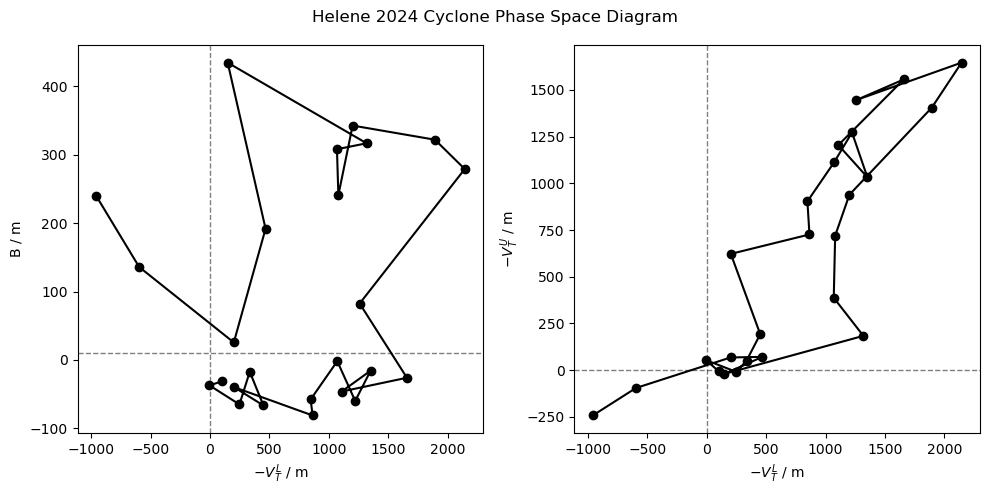

In [15]:
plot_CPS(track_w_CPS_params, title = "Helene 2024 Cyclone Phase Space Diagram")

For the plot on the left, Quadrant I represents an asymmetric warm core system, Quadrant II represents an asymmetric cold core system, Quadrant III represents a symmetric cold core system, and Quadrant IV represents a symmetric warm core system. For the plot on the right, Quadrant I represent a deep warm core, Quadrant II represent a shallow cold core, Quadrant III represents a deep cold core, and Quadrant IV represent a shallow warm core. Since the plot_CPS function only has the arguments of the CPS parameters and the title of the plot, we can utilize Matplotlib to label the quadrants accordingly.

<div class="alert alert-block alert-info">
<b>Note:</b> ChatGPT helped write the code to get the labeling to work, in which the solution was that the plot_CPS function closes the plot after it runs, so we force it to not close, allowing us to utilize Matplotlib functions to display on the plot. I added comments in the code cell below to better highlight what each section does.
</div>

Text(1609.3845128553833, -236.4318067091208, 'Shallow\nWarm-Core')

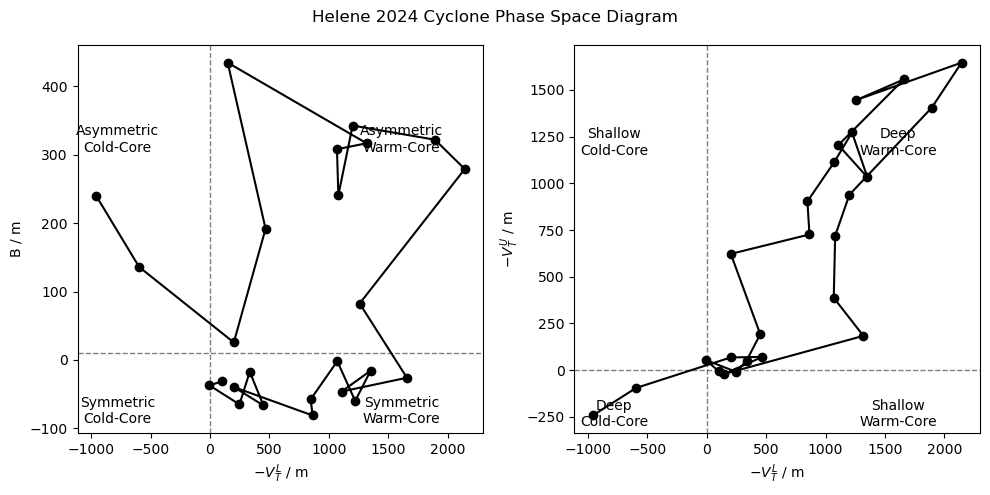

In [16]:
# Force the plot to stay open
_original_show = plt.show
plt.show = lambda *args, **kwargs: None
plot_CPS(track_w_CPS_params, title="Helene 2024 Cyclone Phase Space Diagram")

fig = plt.gcf()     # Returns current figure
axes = fig.axes

# Left Plot
axL = axes[0]
xlim = axL.get_xlim()
ylim = axL.get_ylim()
# Quadrant I
axL.text(0.7 * xlim[1], 0.7 * ylim[1],
         "Asymmetric\nWarm-Core",
         ha="center", va="center", fontsize=10)
# Quadrant II
axL.text(0.7 * xlim[0], 0.7 * ylim[1],
         "Asymmetric\nCold-Core",
         ha="center", va="center", fontsize=10)
# Quadrant III
axL.text(0.7 * xlim[0], 0.7 * ylim[0],
         "Symmetric\nCold-Core",
         ha="center", va="center", fontsize=10)
# Quadrant IV
axL.text(0.7 * xlim[1], 0.7 * ylim[0],
         "Symmetric\nWarm-Core",
         ha="center", va="center", fontsize=10)

# Right Plot
axR = axes[1]
xlim = axR.get_xlim()
ylim = axR.get_ylim()
# Quadrant I
axR.text(0.7 * xlim[1], 0.7 * ylim[1],
         "Deep\nWarm-Core",
         ha="center", va="center", fontsize=10)
# Quadrant II
axR.text(0.7 * xlim[0], 0.7 * ylim[1],
         "Shallow\nCold-Core",
         ha="center", va="center", fontsize=10)
# Quadrant III
axR.text(0.7 * xlim[0], 0.7 * ylim[0],
         "Deep\nCold-Core",
         ha="center", va="center", fontsize=10)
# Quadrant IV
axR.text(0.7 * xlim[1], 0.7 * ylim[0],
         "Shallow\nWarm-Core",
         ha="center", va="center", fontsize=10)

***

## Summary

The cyclone phase space plots of Hurricane Helene can be created by utilizing TempestExtremes and CPyS, which includes inputting ERA5 and HURDAT2 data to calculate the cyclone phase space variables along Helene's track. According to the table of variables and the plots, Helene transitioned from a warm-core system to a cold-core system sometime between 0600 UTC and 1200 UTC on September 28th, 2024. This indicates when the system became post-tropical, where it proceeded to stall over the Southeastern U.S. and experience the Fujiwhara Effect with another extratropical cyclone in the region.

Future work that can be done on this notebook would be to get smoother results on the plots, as well as adding more detail to the plots, such as displaying the intensity (in hPa) at each point. In order to complete these ideas, the CPyS module may need to be further developed; however, utilizing other data sources and Python modules could possibly be done instead (e.g., Matplotlib might be able to add more detail to the plots).

## References

Datasets
- Destination Earth ERA5 Reanalysis Data: {cite:t}'ERA5:2025'

Software
- CPyS: {cite:t}'Bourdin:2024'
- TempestExtremes: {cite:t}'Ullrich:2025'

Information
- Useful Forecast Guidance for the Birth, Transition, and Afterlife Stages of Tropical Cyclones by Robert Hart: {cite:t}'Hart:2019'